# Mobile Price Prediction

## Problem Statement

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('datasets_11167_15520_train.csv')

In [3]:
data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## Domain Analysis

## Basic Checks

In [4]:
data.shape

(2000, 21)

In [5]:
data.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [6]:
data.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [7]:
data.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [8]:
data.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [11]:
data.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [12]:
data.duplicated().sum()

0

In [13]:
data['price_range'].unique()

array([1, 2, 3, 0], dtype=int64)

In [14]:
data['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [15]:
# We have equal number of observations for each category. That means the data is balanced. 

In [16]:
data['touch_screen'].value_counts()

touch_screen
1    1006
0     994
Name: count, dtype: int64

In [17]:
data['blue'].value_counts()

blue
0    1010
1     990
Name: count, dtype: int64

In [18]:
data['wifi'].value_counts()

wifi
1    1014
0     986
Name: count, dtype: int64

In [19]:
data['dual_sim'].value_counts()

dual_sim
1    1019
0     981
Name: count, dtype: int64

In [20]:
data['three_g'].value_counts()

three_g
1    1523
0     477
Name: count, dtype: int64

In [21]:
data['four_g'].value_counts()

four_g
1    1043
0     957
Name: count, dtype: int64

# Exploratory Data Analysis

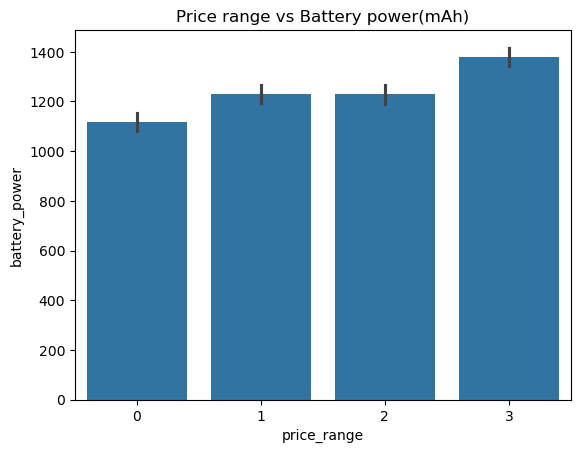

In [22]:
# Battery_power vs price_range graph

sns.barplot(x='price_range', y='battery_power', data=data)
plt.title('Price range vs Battery power(mAh)')
plt.show()

In [23]:
# Insights

# Mobiles having battery_power more than 1300mAh are of high price range which is 3.
# Mobiles having battery_power less than 1200mAh are of low price range which is 0.
# Mobiles with price range 1 and 2 are having almost similar battery power.

### We can see that there is a gradual increase in battery power with increase in price range.

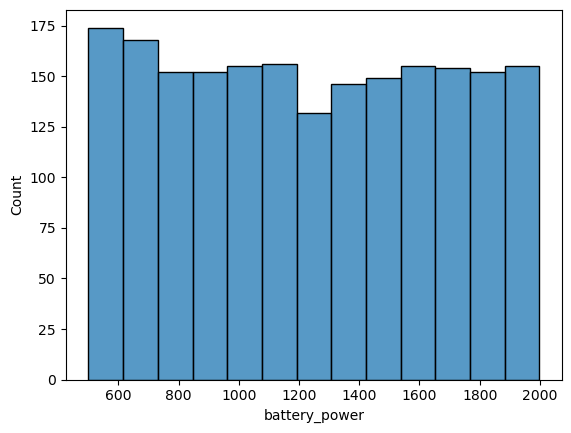

In [24]:
sns.histplot(x='battery_power', data=data)
plt.show()

In [25]:
# Mobiles having battery power 600 is sold more compared to all and next highest sales is for battery power 700.
# The lowest number of sales is for mobiles having battery power 1300.

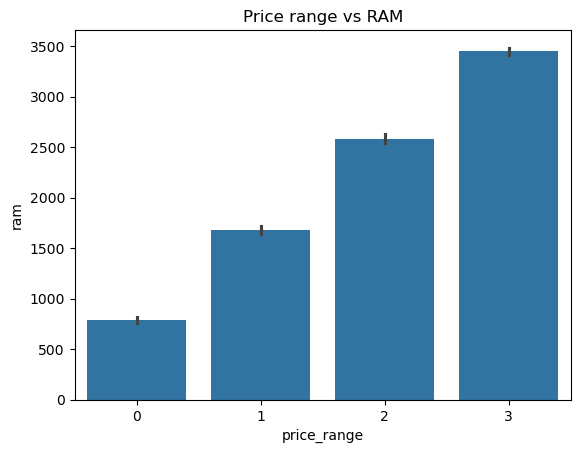

In [26]:
# RAM vs Price range graph 

sns.barplot(data=data, x='price_range', y='ram')
plt.title('Price range vs RAM')
plt.show()

In [27]:
# Insights

# Mobiles which falls under less price range which is 0 are having ram size of less than 1000.
# Mobiles which falls under high price range which is 3 are having ram size of greater than 3000.

### We can clearly say that with increase in price, the ram size increases. 

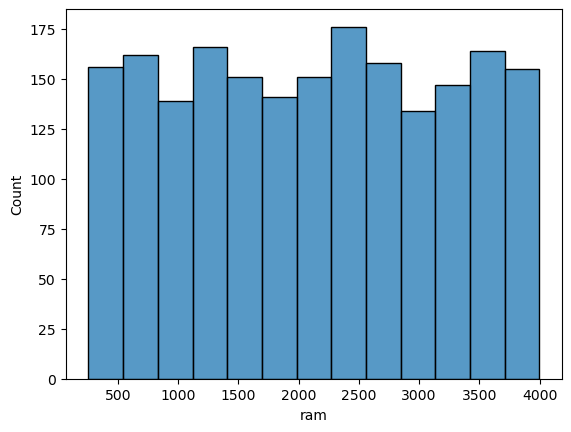

In [28]:
sns.histplot(x='ram', data=data)
plt.show()

In [29]:
# There are more number of sales for mobiles having ram size between 2300 to 2500.

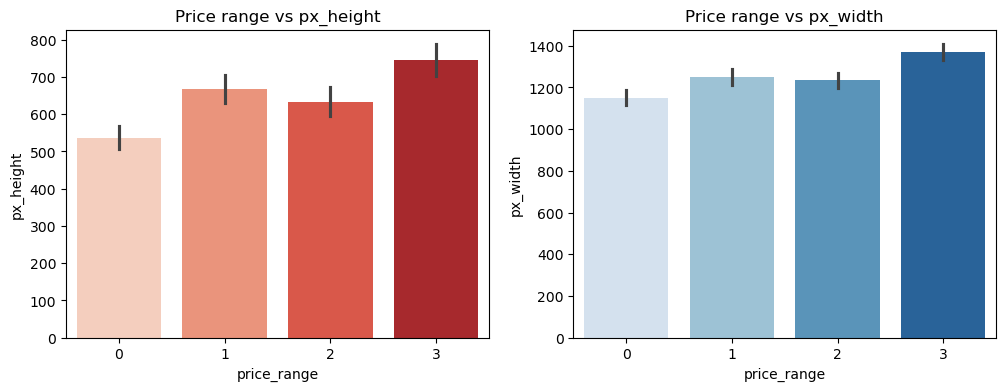

In [30]:
# Price range vs pixel height and width

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.barplot(x='price_range', y='px_height', data=data, palette= 'Reds')
plt.title('Price range vs px_height')

plt.subplot(1,2,2)
sns.barplot(x='price_range', y='px_width', data=data, palette= 'Blues')
plt.title('Price range vs px_width')
plt.show()

In [31]:
## Insights

# Mobiles with high price range are having more px_height which is around 750 and more px_width which is around 1300. 
# Price range 2 and 3 mobiles are having px_width between 1200 to 1300.

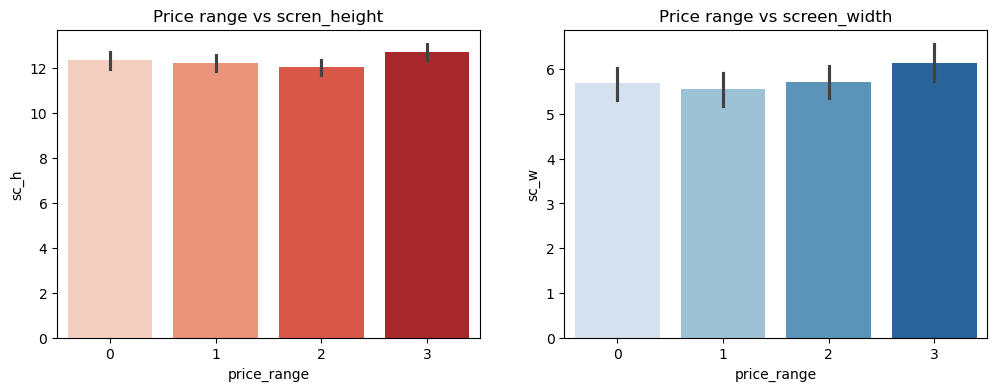

In [32]:
# Price range vs screen height and width

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.barplot(x='price_range', y='sc_h', data=data, palette= 'Reds')
plt.title('Price range vs scren_height')

plt.subplot(1,2,2)
sns.barplot(x='price_range', y='sc_w', data=data, palette= 'Blues')
plt.title('Price range vs screen_width')
plt.show()

In [33]:
## Insights

## Price range doesn't get effected by the screen height and width. Almost all mobiles with different price ranges are having similar screen height and 
#     width, with slight differences in number.
## For all the price ranges, screen height is around 12 and 13,, and Screen width is between 5.5 and 6.

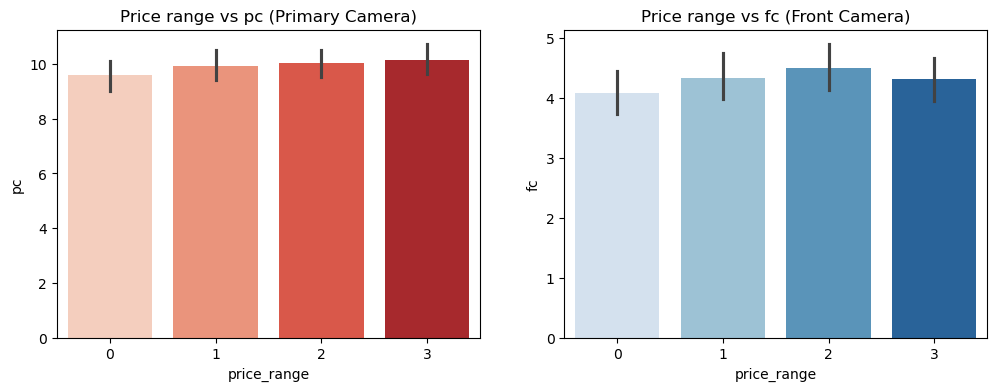

In [34]:
## Price range vs pc and fc

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.barplot(x='price_range', y='pc', data=data, palette= 'Reds')
plt.title('Price range vs pc (Primary Camera)')

plt.subplot(1,2,2)
sns.barplot(x='price_range', y='fc', data=data, palette= 'Blues')
plt.title('Price range vs fc (Front Camera)')
plt.show()

In [35]:
# Insights

# For all price ranges, the pc is almost similar which is above 9. It is little bit high for price range 2.
# The fc is above 4 for all price ranges, and fc is high for price range 2 mobiles.

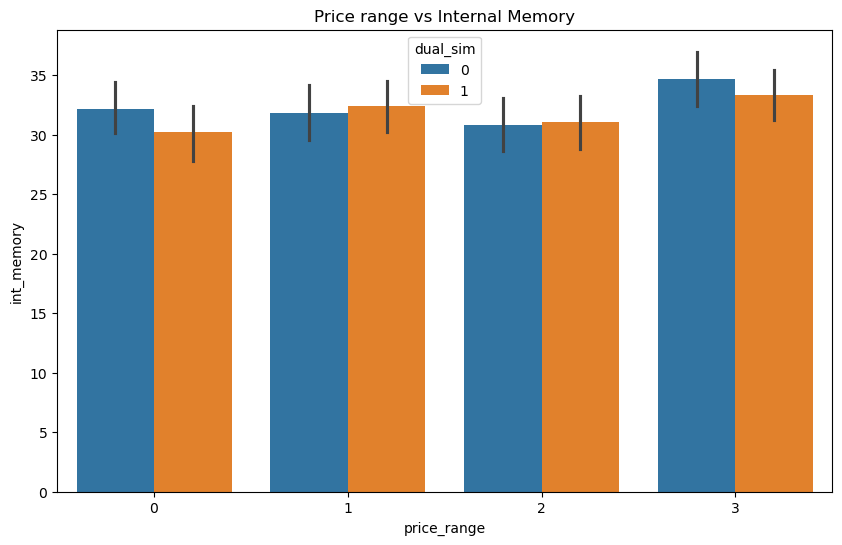

In [36]:
## Price range vs Internal memory

plt.figure(figsize=(10,6))
sns.barplot(data=data, x='price_range', y='int_memory', hue='dual_sim')
plt.title('Price range vs Internal Memory')
plt.show()

In [37]:
## Insights

# Mobiles which are of lowest price range 0 are having more than 30GB internal memory for non dual sim. And for dual sim it is 30GB only.
# Mobiles with non dual sim of highest price range are having more internal memory compared to mobiles with non dual sim of same price range.
# For the price ranges 0 and 3, mobiles with dual sim are having less internal memory compared to mobiles with single sim.
# For price range 2 both dual sim and single sim mobiles are having almost similar internal memory which is around 30GB. 

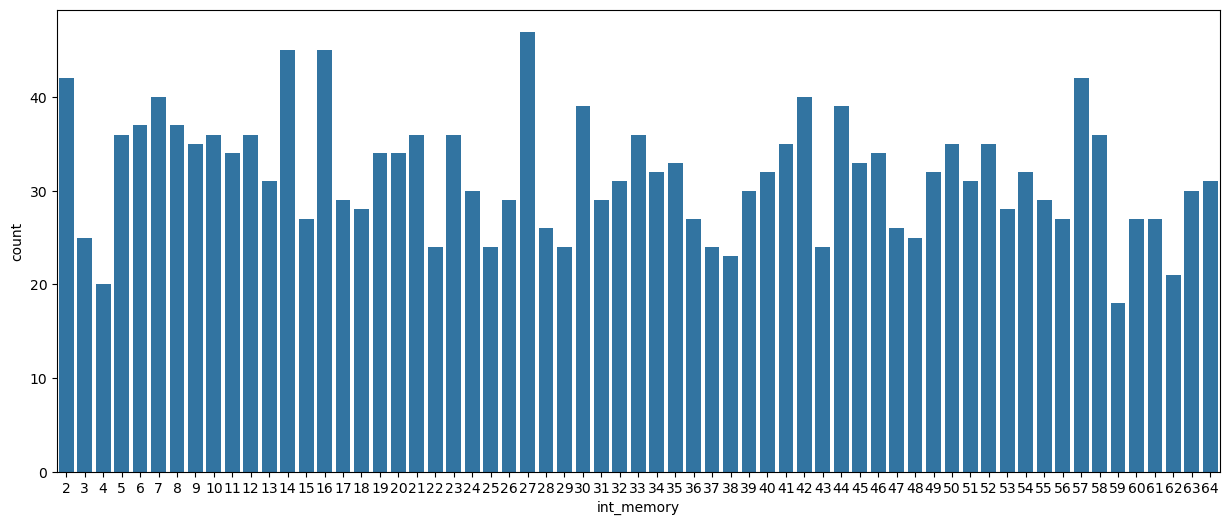

In [38]:
plt.figure(figsize=(15,6))
sns.countplot(data=data, x='int_memory')
plt.show()

In [39]:
# There are more number of sales for mobiles having internal memory as 27GB,, and the next almost similar sales for mobiles having internal memory 
#    as 14 and 16GB.
# The next is almost similar number of sales for mobiles having internal memory as 2GB and 57GB.
# The least number of sales is for mobiles having internal memory as 59GB.

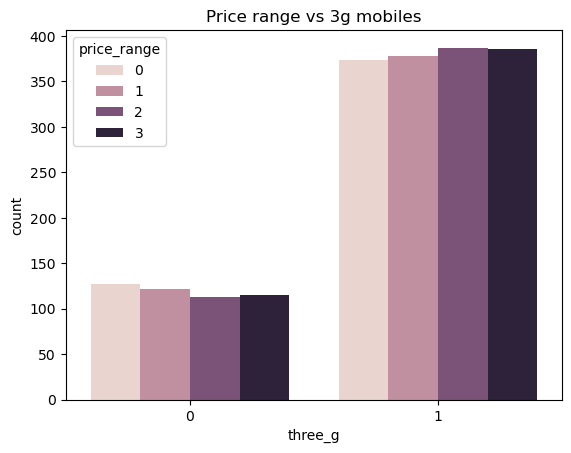

In [40]:
# Price range vs 3g

sns.countplot(x='three_g', hue='price_range', data=data)
plt.title('Price range vs 3g mobiles')
plt.show()

In [41]:
## Insights

# 1 is for 3g mobiles
# we can say that in 3g category, the mobiles belonging to price range 2 are highest compared to all.

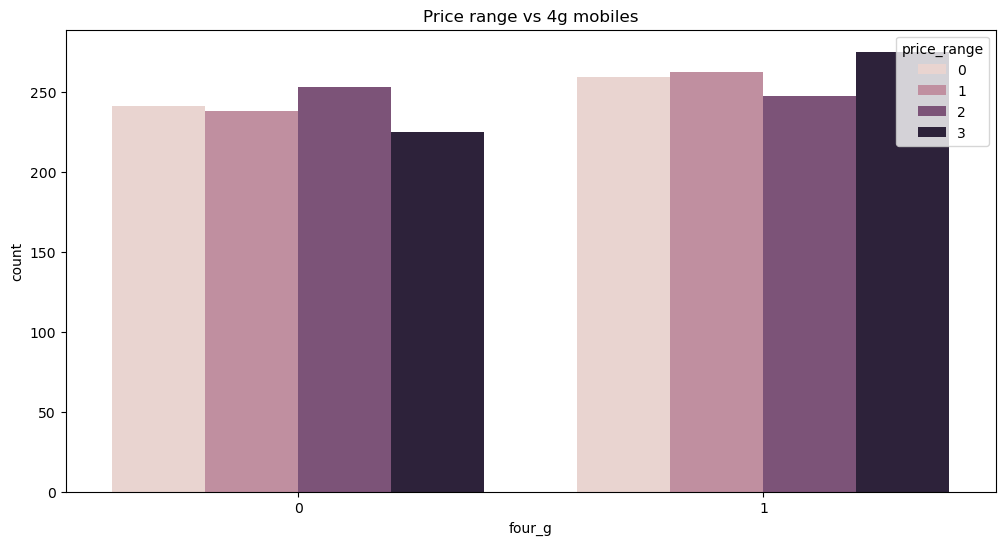

In [42]:
# Price range vs 4g

plt.figure(figsize=(12,6))
sns.countplot(x='four_g', hue='price_range', data=data)
plt.title('Price range vs 4g mobiles')
plt.show()

In [43]:
## Insights

# 1 is for 4g.
# In 4g category, the mobiles belonging to highest price range(3) are having more sales compared to all.

### Correlation Heatmap

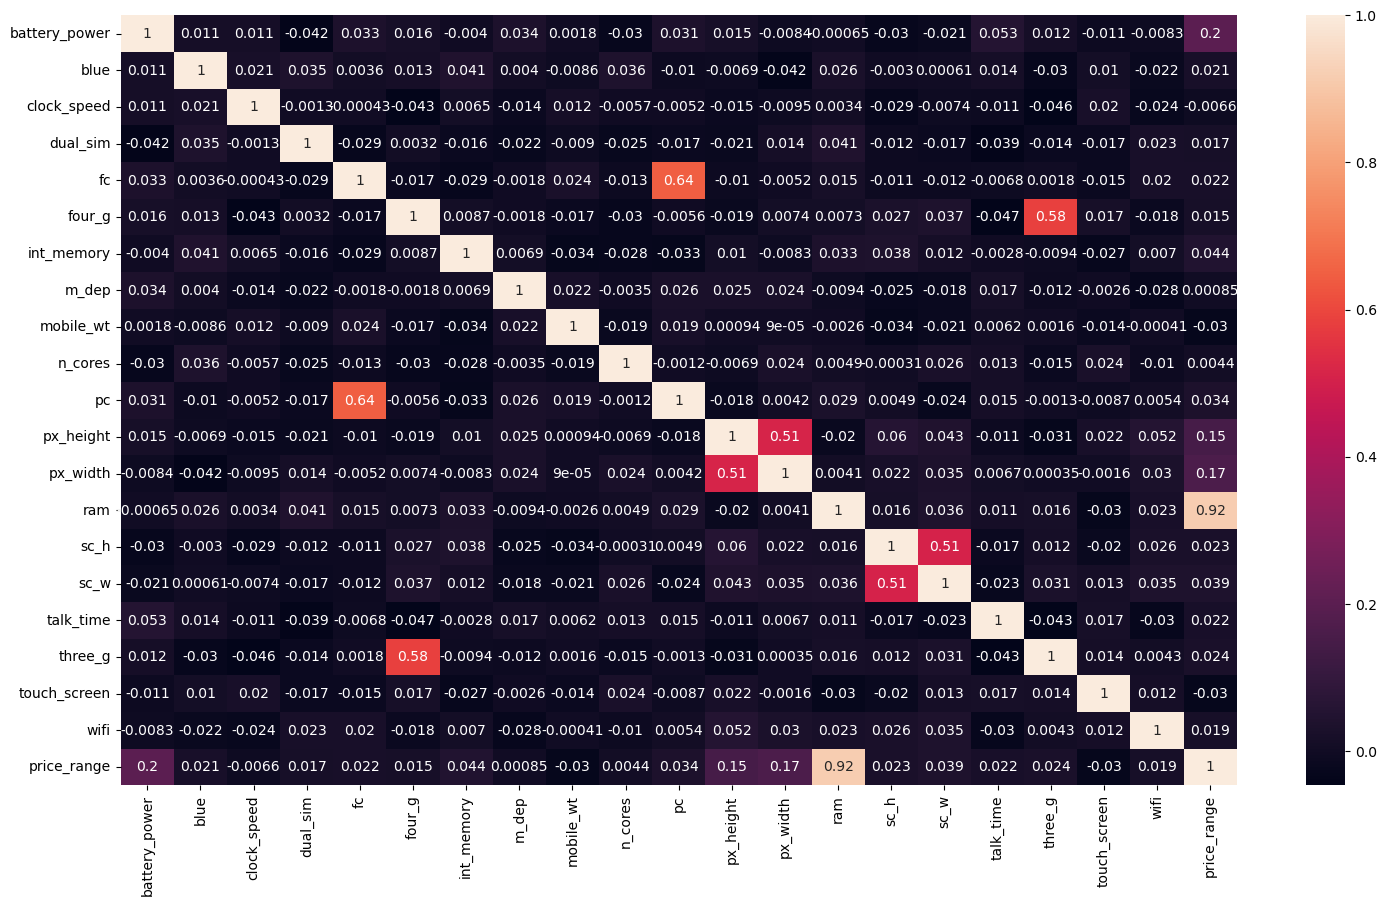

In [44]:
# Correlation between Independent and Dependent features

plt.figure(figsize=(18,10))
sns.heatmap(data.corr(),annot=True)
plt.show()

# Model Building

### Split data into Training and Testing sets

In [45]:
X= data.drop(['price_range'], axis=1)

In [46]:
y=data['price_range']

In [47]:
X.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [48]:
y.head()

0    1
1    2
2    2
3    2
4    1
Name: price_range, dtype: int64

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Selection

We understood that it is a Classification problem by the output for which we have to calculate mobile price range having different price ranges  
as 0,1,2,3. \
So we can use Classifier algorithmns such as Logistic Regression, KNN Classifier, Decision Tree Classifier, Random Forest Classifier. \
Compare values of all the models and keep the best one to predict the values.

# Logistic Regression

In [50]:
from sklearn.linear_model import LogisticRegression

In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [52]:
lr= LogisticRegression()

In [53]:
lr.fit(X_train, y_train)

LogisticRegression()

In [54]:
y_pred_lr = lr.predict(X_test)

In [55]:
accuracy_score(y_test, y_pred_lr)

0.6325

In [56]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.75      0.79       105
           1       0.52      0.51      0.51        91
           2       0.48      0.50      0.49        92
           3       0.69      0.73      0.71       112

    accuracy                           0.63       400
   macro avg       0.63      0.62      0.62       400
weighted avg       0.64      0.63      0.63       400



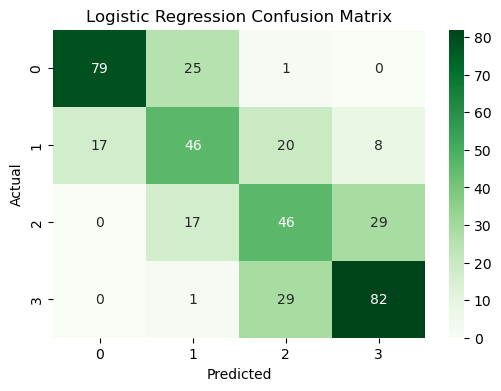

In [57]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
## From the Confusion Matrix, we can say that the model is doing more mistakes while predicting the price of a mobile.
## Since it's accuracy score is also low, it is not a good choice to make predictions.

# KNN Classifier

In [59]:
from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier(n_neighbors=10)                

In [60]:
## For n=10, we are getting highest accuracy score which is 0.95, hence we continued with n value as 10.
# For other n values we are getting less accuracy score which are-- n=8 it is 0.94, n=9 it is 0.952, n=11 it is 0.951, n=12 it is 0.94 

In [61]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [62]:
knn.score(X_train, y_train)

0.9525

In [63]:
y_pred_kn= knn.predict(X_test)

In [64]:
accuracy_score(y_test, y_pred_kn)

0.95

In [65]:
print(classification_report(y_test, y_pred_kn))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       105
           1       0.93      0.96      0.94        91
           2       0.89      0.92      0.91        92
           3       1.00      0.92      0.96       112

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



In [66]:
from sklearn.metrics import confusion_matrix

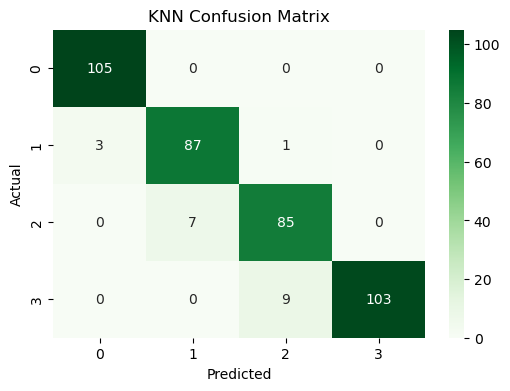

In [67]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_kn)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [68]:
## From the Confusion Matrix, we can say that the model is making correct predictions most of the times. 
## For Price range 3, it made all predictions correctly. 
## For price range 1 and 2 it made few mistakes and for price range 0 also it almost made correct predictions, only 3 of them are wrong.
## Since its accuracy score is also high which is 0.95, we can consider this model for making predictions.

# Decision Tree Classifier

In [69]:
from sklearn.tree import DecisionTreeClassifier
dt= DecisionTreeClassifier(random_state=42)

In [70]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [71]:
y_pred_dt= dt.predict(X_test)

In [72]:
accuracy_score(y_test, y_pred_dt)

0.8325

In [73]:
print('Decision Tree:')
print(classification_report(y_test, y_pred_dt))

Decision Tree:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       105
           1       0.75      0.84      0.79        91
           2       0.80      0.70      0.74        92
           3       0.86      0.90      0.88       112

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



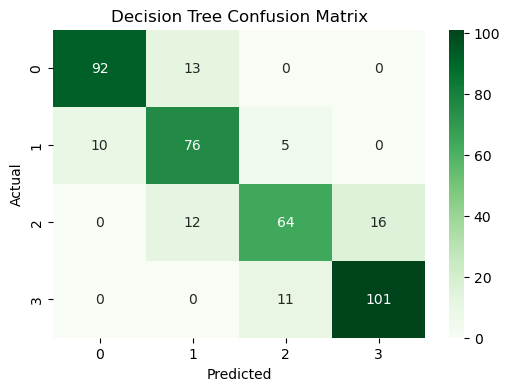

In [74]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

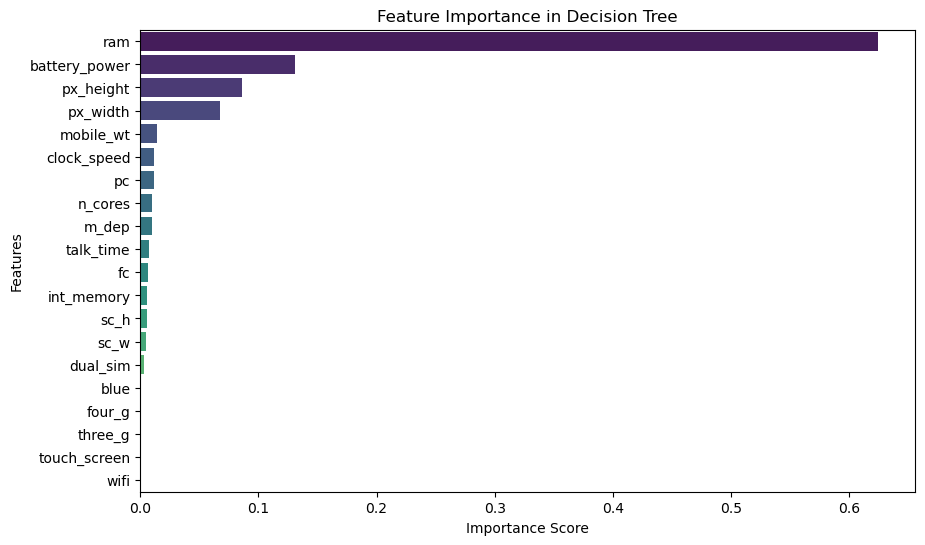

In [75]:
# Feature Importance
feature_importance = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')
plt.title("Feature Importance in Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# Random Forest Classifier

In [76]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(n_estimators=105, random_state=42)

In [77]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=105, random_state=42)

In [78]:
y_pred_rf= rf.predict(X_test)

In [79]:
accuracy_score(y_test, y_pred_rf)

0.8925

In [80]:
print('Random Forest:')
print(classification_report(y_test, y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       105
           1       0.89      0.87      0.88        91
           2       0.79      0.86      0.82        92
           3       0.93      0.88      0.90       112

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.90      0.89      0.89       400



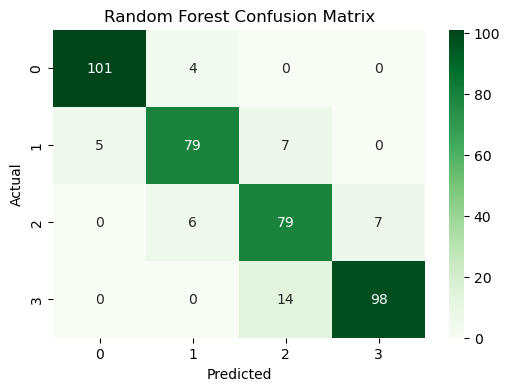

In [81]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

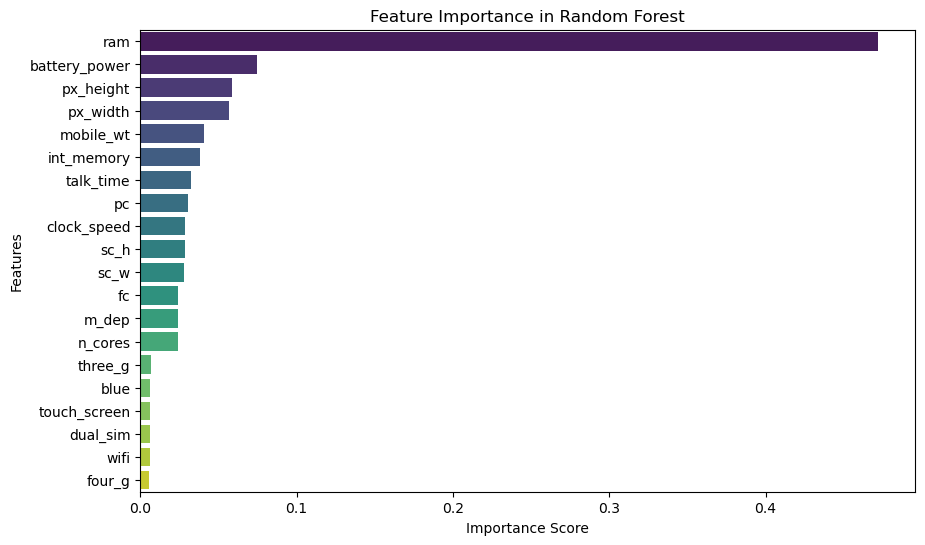

In [82]:
# Feature Importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance, y=feature_importance.index, palette='viridis')
plt.title("Feature Importance in Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# Hyper Parameter Tuning

In [83]:
from sklearn.model_selection import GridSearchCV

In [84]:
' Tuning Decision Tree ----- GridSearch' 


dt=DecisionTreeClassifier(random_state=42)
param_dt= {'max_depth':[None,2,10,15],
           'min_samples_split':[2,5,10],
           'min_samples_leaf':[1,2,5]}
grid_dt= GridSearchCV(dt, param_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train, y_train)

best_dt= grid_dt.best_estimator_
y_pred_dt_tuned= best_dt.predict(X_test)

In [85]:
print('Decision Tree --- Tuned')
print("Accuracy:", accuracy_score(y_test, y_pred_dt_tuned))

Decision Tree --- Tuned
Accuracy: 0.8525


In [86]:
from sklearn.model_selection import RandomizedSearchCV

In [87]:
'   Tuning Decision Tree ---- RandomSearch '


dt=DecisionTreeClassifier(random_state=42)
param_dt = {'max_depth': [None, 2,10,15],
            'min_samples_split': [2,5,10],
            'min_samples_leaf': [1,2,5]}
random_dt= RandomizedSearchCV(dt, param_dt, cv=5, scoring='accuracy', n_jobs=-1)
random_dt.fit(X_train, y_train)

best_dt= random_dt.best_estimator_
y_pred_dt_tuned_random= best_dt.predict(X_test)

In [88]:
print('Decision Tree --- Tuned(RandomizedSearchCV)')
print("Accuracy:", accuracy_score(y_test, y_pred_dt_tuned_random))

Decision Tree --- Tuned(RandomizedSearchCV)
Accuracy: 0.8525


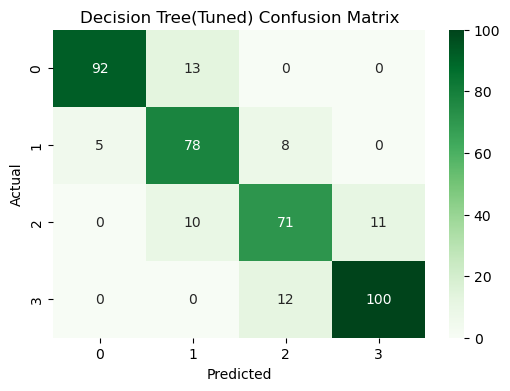

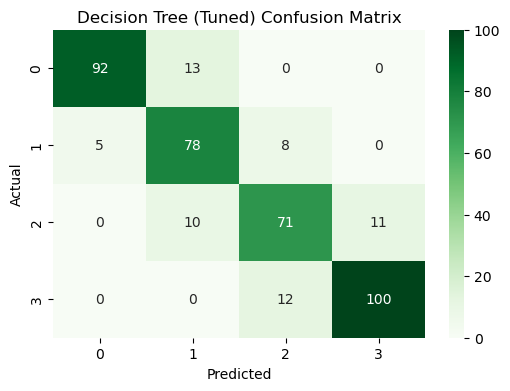

In [89]:
# Confusion Matrix for Decision Tree (Tuned) with GridSearch CV and RandomSearch CV

cm = confusion_matrix(y_test, y_pred_dt_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree(Tuned) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

cm = confusion_matrix(y_test, y_pred_dt_tuned_random)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree (Tuned) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [90]:
' Tuning Random Forest ---- GridSearch '


rf=RandomForestClassifier(random_state=42)
param_rf= {'n_estimators': [50,100,200],
           'max_depth':[None,2,10,15],
           'min_samples_split':[2,5,10],
           'min_samples_leaf':[1,2,5]}
grid_rf= GridSearchCV(rf, param_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf= grid_rf.best_estimator_
y_pred_rf_tuned= best_rf.predict(X_test)

In [91]:
grid_rf.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [92]:
print('Random Forest --- Tuned')
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))

Random Forest --- Tuned
Accuracy: 0.8925


In [93]:
'   Tuning Random Forest ---- RandomSearch '


rf=RandomForestClassifier(random_state=42)
param_rf= {'n_estimators': [100,200,300],
           'max_depth':[None,5,10,15],
           'min_samples_split':[2,5,10],
           'min_samples_leaf':[1,3,5]}
random_rf= RandomizedSearchCV(rf, param_rf, cv=5, scoring='accuracy', n_jobs=-1)
random_rf.fit(X_train, y_train)

best_rf= random_rf.best_estimator_
y_pred_rf_tuned_random= best_rf.predict(X_test)

In [94]:
print('Random Forest --- Tuned(RandomizedSearchCV)')
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned_random))

Random Forest --- Tuned(RandomizedSearchCV)
Accuracy: 0.8875


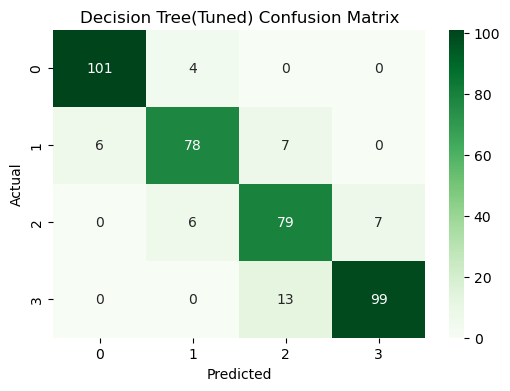

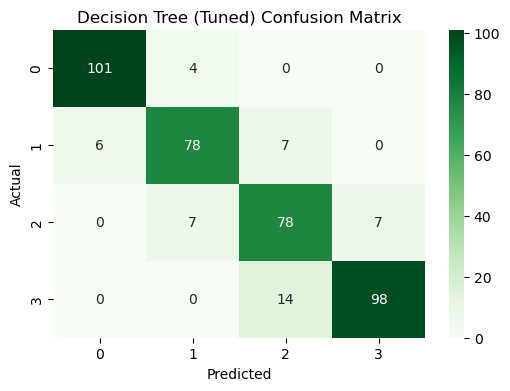

In [95]:
# Confusion Matrix for Random Forest (Tuned) with GridSearch CV and RandomSearch CV

cm = confusion_matrix(y_test, y_pred_rf_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree(Tuned) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

cm = confusion_matrix(y_test, y_pred_rf_tuned_random)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree (Tuned) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model Performance Comparision 

In [96]:
results={'Model':['Logistic Regression','KNN Classifier','Decision Tree Classifier','Decision Tree (Tuned-- GridSearch)',
                  'Decision Tree (Tuned-- RandomSearch)','Random Forest Classifier', 'Random Forest (Tuned-- GridSearch)', 'Random Forest (Tuned-- RandomSearch)'],
         'accuracy_score': ['0.63','0.95','0.83','0.85','0.85','0.89','0.89','0.89']}

In [97]:
compare_results= pd.DataFrame(results)

In [98]:
compare_results

,Model,accuracy_score
0,Logistic Regression,0.63
1,KNN Classifier,0.95
2,Decision Tree Classifier,0.83
3,Decision Tree (Tuned-- GridSearch),0.85
4,Decision Tree (Tuned-- RandomSearch),0.85
5,Random Forest Classifier,0.89
6,Random Forest (Tuned-- GridSearch),0.89
7,Random Forest (Tuned-- RandomSearch),0.89


# Save the best model

In [99]:
## Save the best model i.e., KNN Classifier to reuse it again.

In [100]:
import pickle

In [101]:
# Open a file where you want to store the data and dump information into that file

with open('mobile_knn.pkl', 'wb') as f:
    pickle.dump(knn,f)

print('Best model saved as mobile_knn.pkl')

Best model saved as mobile_knn.pkl


In [102]:
## Load the model from file

with open('mobile_knn.pkl', 'rb') as f:
    loaded_model=pickle.load(f)

# Predictions

In [103]:
test_data = pd.DataFrame({
    'battery_power': [1500],
    'blue': [1],
    'clock_speed': [2.2],
    'dual_sim': [1],
    'fc': [5],
    'four_g': [1],
    'int_memory': [62],
    'm_dep': [0.6],
    'mobile_wt': [190],
    'n_cores': [8],
    'pc': [13],
    'px_height': [1300],
    'px_width': [1500],
    'ram': [3800],
    'sc_h': [15],
    'sc_w': [8],
    'talk_time': [20],
    'three_g': [1],
    'touch_screen': [1],
    'wifi': [1]
})


In [104]:
test_data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1500,1,2.2,1,5,1,62,0.6,190,8,13,1300,1500,3800,15,8,20,1,1,1


In [105]:
## Predicting Mobile Price range

pred_pricerange = loaded_model.predict(test_data)
print("Predicted Price Range:", pred_pricerange)

Predicted Price Range: [3]


# Final Report